# MCO2 Numerical Data Analysis Notebook

## Setup

Import dependencies

In [18]:
# %pip install "numpy<2.0"

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [20]:
sns.set_theme(style="whitegrid", context="notebook")


Load CSVs

In [21]:
typing_test_df = pd.read_csv('typing_test_data.csv')
nasa_tlx_df = pd.read_csv('nasa_tlx.csv')

## Exploratory Data Analysis

### Exploring `typing_test_data.csv`

In [22]:
typing_test_df

,Participant Number,GroupNumber,Text_60_WPM,Text_60_Accuracy,Text_60_ErrorRate,Text_60_MouseTime,Text_60_Clicks,Text_60_Backspaces,Text_60_Scrolls,Text_60_TotalTime,...,Prog_100_Accuracy,Prog_100_ErrorRate,Prog_100_MouseTime,Prog_100_Clicks,Prog_100_Backspaces,Prog_100_Scrolls,Prog_100_TotalTime,Prog_100_CorrectChars,Prog_100_IncorrectFixed,Prog_100_IncorrectNotFixed
0,2,2,89.0,92.4,7.6,0.045,0,25,0,40.982,...,83.5,16.8,2.184,1,66,4,113.118,327,66,0
1,3,3,73.7,84.9,15.1,0.000,0,54,0,49.531,...,85.4,14.2,0.000,0,54,0,64.878,327,54,0
2,4,4,61.7,89.6,10.4,0.000,0,40,0,67.079,...,94.3,6.0,0.000,0,18,0,67.785,281,18,0
3,5,5,68.8,93.5,6.5,0.000,0,24,0,60.183,...,90.9,9.1,0.000,0,28,0,102.489,281,28,0
4,12,6,53.1,93.8,6.2,0.000,0,23,0,77.976,...,66.9,12.0,0.000,0,29,0,120.000,213,29,0
5,11,5,57.1,95.6,4.4,0.000,0,16,0,72.495,...,56.4,10.6,0.000,0,26,0,120.000,244,26,3
6,7,1,82.0,92.7,7.3,0.000,0,24,0,44.502,...,89.3,10.7,0.000,0,39,0,66.300,327,39,0
7,8,2,66.9,90.4,9.0,0.000,0,30,0,54.191,...,89.7,9.2,0.000,0,33,0,94.726,327,33,0
8,9,3,70.1,94.7,5.3,3.009,1,17,0,52.004,...,89.1,10.9,0.000,0,40,0,91.309,327,40,0
9,13,1,55.2,94.7,5.3,0.000,0,17,0,66.053,...,85.4,14.6,0.000,0,56,0,112.535,327,56,0


In [23]:
typing_test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33 entries, 0 to 32
Data columns (total 68 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Participant Number          33 non-null     int64  
 1   GroupNumber                 33 non-null     int64  
 2   Text_60_WPM                 33 non-null     float64
 3   Text_60_Accuracy            33 non-null     float64
 4   Text_60_ErrorRate           33 non-null     float64
 5   Text_60_MouseTime           33 non-null     float64
 6   Text_60_Clicks              33 non-null     int64  
 7   Text_60_Backspaces          33 non-null     int64  
 8   Text_60_Scrolls             33 non-null     int64  
 9   Text_60_TotalTime           33 non-null     float64
 10  Text_60_CorrectChars        33 non-null     int64  
 11  Text_60_IncorrectFixed      33 non-null     int64  
 12  Text_60_IncorrectNotFixed   33 non-null     int64  
 13  Num_60_WPM                  33 non-nu

In [24]:
typing_test_df.describe()

,Participant Number,GroupNumber,Text_60_WPM,Text_60_Accuracy,Text_60_ErrorRate,Text_60_MouseTime,Text_60_Clicks,Text_60_Backspaces,Text_60_Scrolls,Text_60_TotalTime,...,Prog_100_Accuracy,Prog_100_ErrorRate,Prog_100_MouseTime,Prog_100_Clicks,Prog_100_Backspaces,Prog_100_Scrolls,Prog_100_TotalTime,Prog_100_CorrectChars,Prog_100_IncorrectFixed,Prog_100_IncorrectNotFixed
count,33.000000,33.000000,33.000000,33.000000,33.000000,33.000000,33.000000,33.000000,33.0,33.000000,...,33.000000,33.000000,33.000000,33.000000,33.000000,33.000000,33.000000,33.000000,33.000000,33.000000
mean,17.242424,3.333333,69.278788,92.275758,7.800000,0.519636,0.272727,27.363636,0.0,60.855515,...,86.800000,11.339394,0.448848,0.484848,37.878788,0.121212,97.962848,292.030303,37.878788,0.333333
std,10.059294,1.670828,18.638162,3.520035,3.959561,2.157308,1.097518,14.039716,0.0,19.694996,...,7.954676,4.305588,1.675085,1.954501,16.661628,0.696311,20.362716,32.043413,16.661628,0.853913
min,1.000000,1.000000,34.200000,82.600000,3.600000,0.000000,0.000000,12.000000,0.0,34.316000,...,56.400000,3.400000,0.000000,0.000000,10.000000,0.000000,63.357000,213.000000,10.000000,0.000000
25%,9.000000,2.000000,56.500000,90.400000,5.000000,0.000000,0.000000,17.000000,0.0,49.666000,...,84.500000,9.100000,0.000000,0.000000,26.000000,0.000000,79.323000,281.000000,26.000000,0.000000
50%,17.000000,3.000000,69.800000,93.500000,6.500000,0.000000,0.000000,24.000000,0.0,57.928000,...,88.100000,10.900000,0.000000,0.000000,35.000000,0.000000,103.653000,281.000000,35.000000,0.000000
75%,25.000000,5.000000,82.000000,95.000000,9.300000,0.000000,0.000000,32.000000,0.0,68.168000,...,90.900000,14.200000,0.000000,0.000000,52.000000,0.000000,120.000000,327.000000,52.000000,0.000000
max,35.000000,6.000000,106.000000,96.400000,21.700000,12.020000,6.000000,70.000000,0.0,120.000000,...,96.600000,22.400000,9.251000,11.000000,70.000000,4.000000,120.000000,327.000000,70.000000,3.000000


### Exploring `nasa_tlx.csv`

#### Typing test dataset: structural overview


In [25]:
typing_structure = (
    pd.DataFrame({
        "dtype": typing_test_df.dtypes,
        "unique": typing_test_df.nunique(),
        "missing": typing_test_df.isna().sum(),
    })
    .sort_values("unique", ascending=False)
)
typing_structure.head(10)


,dtype,unique,missing
Participant Number,int64,33,0
Text_60_TotalTime,float64,33,0
Num_100_WPM,float64,33,0
Text_100_TotalTime,float64,33,0
Text_100_WPM,float64,33,0
Num_60_WPM,float64,33,0
Prog_100_WPM,float64,32,0
Prog_60_WPM,float64,32,0
Text_60_WPM,float64,32,0
Prog_100_Accuracy,float64,31,0


#### Typing test dataset: key performance metrics


In [26]:
wpm_cols = [
    "Text_60_WPM",
    "Num_60_WPM",
    "Prog_60_WPM",
    "Text_100_WPM",
    "Num_100_WPM",
    "Prog_100_WPM",
]
accuracy_cols = [
    "Text_60_Accuracy",
    "Num_60_Accuracy",
    "Prog_60_Accuracy",
    "Text_100_Accuracy",
    "Num_100_Accuracy",
    "Prog_100_Accuracy",
]
key_metrics = (
    typing_test_df[wpm_cols + accuracy_cols]
    .agg(["mean", "std", "min", "max"])
    .T.round(2)
)
key_metrics


,mean,std,min,max
Text_60_WPM,69.28,18.64,34.2,106.0
Num_60_WPM,29.19,8.99,8.9,46.6
Prog_60_WPM,38.38,12.65,3.9,59.3
Text_100_WPM,70.31,19.48,32.2,101.0
Num_100_WPM,29.54,7.74,16.3,45.3
Prog_100_WPM,37.38,11.93,15.4,61.9
Text_60_Accuracy,92.28,3.52,82.6,96.4
Num_60_Accuracy,85.94,10.08,37.7,95.1
Prog_60_Accuracy,87.87,13.73,14.9,97.6
Text_100_Accuracy,90.99,4.69,81.6,98.1


#### Typing test dataset: group-level WPM comparison


In [27]:
group_wpm_summary = (
    typing_test_df.groupby("GroupNumber")[wpm_cols]
    .agg(["mean", "std"])
    .round(2)
)
group_wpm_summary


Text_60_WPM        Num_60_WPM        Prog_60_WPM         \
                   mean    std       mean    std        mean    std   
GroupNumber                                                           
1                 65.67  24.41      25.15  12.71       38.10  20.92   
2                 70.98  20.58      26.48   8.01       36.10   8.53   
3                 75.86  26.57      35.68  11.74       41.46  13.51   
4                 67.40   8.88      29.84   3.90       38.79   8.43   
5                 72.16  10.28      31.14   7.46       42.70  11.68   
6                 63.60  24.44      27.62   8.38       32.22  13.48   

            Text_100_WPM        Num_100_WPM        Prog_100_WPM         
                    mean    std        mean    std         mean    std  
GroupNumber                                                             
1                  66.38  20.16       32.57  10.23        43.95  14.97  
2                  64.40  21.44       27.47   7.55        35.07   9.55  
3                  71.72  24.72       34.68  11.20        44.72  13.38  
4                  75.69  17.95       27.13   5.55        36.41   7.95  
5                  76.54  16.65       29.42   2.92        33.64  11.96  
6                  66.08  22.68       26.08   5.45        28.22  10.63

#### Typing test dataset: WPM distributions


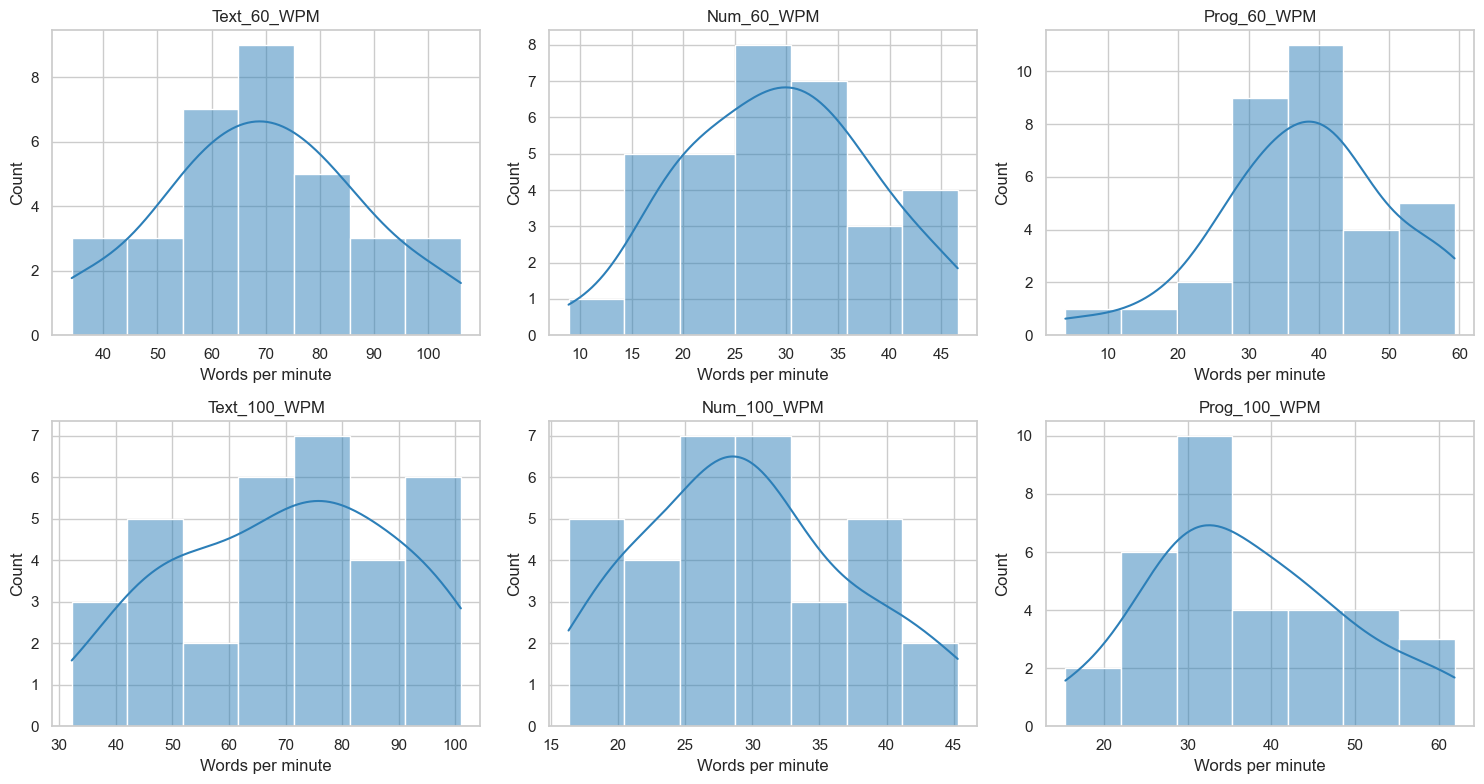

In [28]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharey=False)
for col, ax in zip(wpm_cols, axes.ravel()):
    sns.histplot(typing_test_df[col], kde=True, ax=ax, color="#2c7fb8")
    ax.set_title(col)
    ax.set_xlabel("Words per minute")
plt.tight_layout()


#### Typing test dataset: correlation between WPM and accuracy


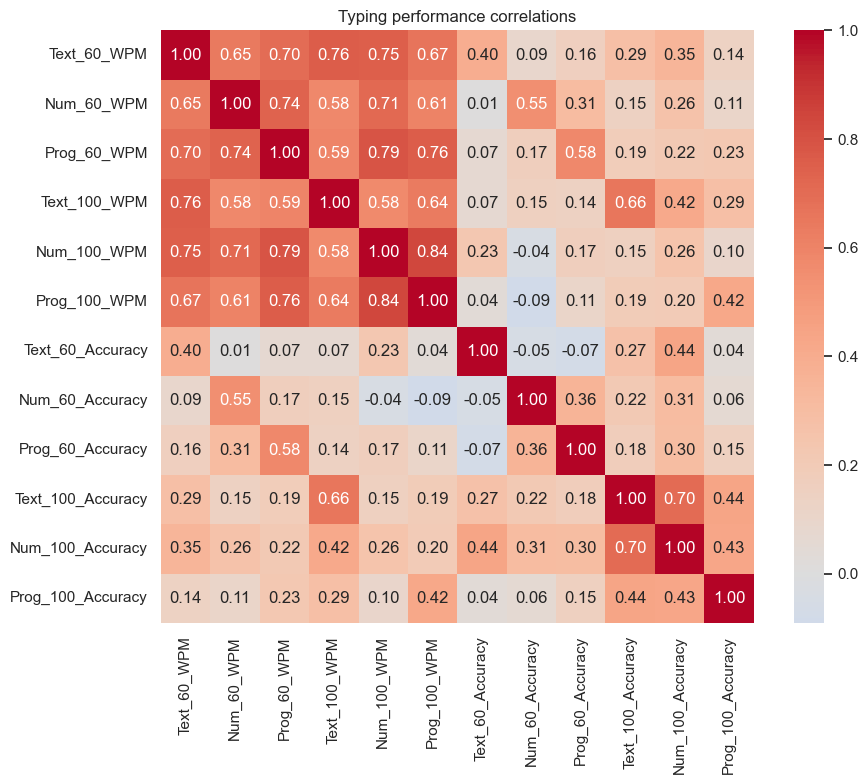

In [29]:
corr_cols = wpm_cols + accuracy_cols
corr_matrix = typing_test_df[corr_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0, annot=True, fmt=".2f", square=True)
plt.title("Typing performance correlations")
plt.tight_layout()


In [30]:
nasa_tlx_df

,Participant Number,Original Keyboard,Keyboard Type,Task Type,Mental Demand,Physical Demand,Temporal Demand,Performance,Effort,Frustration Level
0,15,Both,1,A,1,1,1,10,1,1
1,15,Both,1,B,7,8,4,5,5,2
2,15,Both,1,C,3,6,1,5,4,2
3,15,Both,2,A,1,1,1,7,1,1
4,15,Both,2,B,6,9,3,5,6,2
...,...,...,...,...,...,...,...,...,...,...
193,10,60,1,B,6,5,6,4,6,5
194,10,60,1,C,5,4,5,5,5,5
195,10,60,2,A,3,4,4,6,4,2
196,10,60,2,B,8,4,6,4,6,5


In [31]:
nasa_tlx_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 198 entries, 0 to 197
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Participant Number  198 non-null    int64 
 1   Original Keyboard   198 non-null    object
 2   Keyboard Type       198 non-null    int64 
 3   Task Type           198 non-null    object
 4   Mental Demand       198 non-null    int64 
 5   Physical Demand     198 non-null    int64 
 6   Temporal Demand     198 non-null    int64 
 7   Performance         198 non-null    int64 
 8   Effort              198 non-null    int64 
 9   Frustration Level   198 non-null    int64 
dtypes: int64(8), object(2)
memory usage: 15.6+ KB


In [32]:
nasa_tlx_df.describe()

,Participant Number,Keyboard Type,Mental Demand,Physical Demand,Temporal Demand,Performance,Effort,Frustration Level
count,198.000000,198.000000,198.000000,198.000000,198.000000,198.000000,198.000000,198.000000
mean,17.242424,1.500000,4.318182,3.969697,4.176768,6.853535,4.444444,3.323232
std,9.930817,0.501267,2.092960,2.165510,2.406435,2.235787,2.283119,2.307913
min,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000,1.000000,1.000000
25%,9.000000,1.000000,3.000000,2.000000,2.000000,5.000000,3.000000,2.000000
50%,17.000000,1.500000,4.000000,4.000000,4.000000,7.000000,4.000000,2.000000
75%,25.000000,2.000000,6.000000,6.000000,6.000000,9.000000,6.000000,4.000000
max,35.000000,2.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000


#### NASA TLX dataset: categorical overview


In [33]:
category_counts = {
    "Keyboard Type": nasa_tlx_df["Keyboard Type"].value_counts().sort_index(),
    "Task Type": nasa_tlx_df["Task Type"].value_counts().sort_index(),
    "Original Keyboard": nasa_tlx_df["Original Keyboard"].value_counts().sort_values(ascending=False).head(5),
}
for label, series in category_counts.items():
    display(pd.DataFrame(series).rename(columns={series.name: "count"}))


,count
Keyboard Type,
1,99
2,99


,count
Task Type,
A,66
B,66
C,66


,count
Original Keyboard,
100,60
Missing,42
60,30
75,24
Laptop,12


#### NASA TLX dataset: workload scores by keyboard and task


In [34]:
workload_cols = [
    "Mental Demand",
    "Physical Demand",
    "Temporal Demand",
    "Performance",
    "Effort",
    "Frustration Level",
]
keyboard_summary = nasa_tlx_df.groupby("Keyboard Type")[workload_cols].mean().round(2)
task_summary = nasa_tlx_df.groupby("Task Type")[workload_cols].mean().round(2)
keyboard_summary, task_summary


(               Mental Demand  Physical Demand  Temporal Demand  Performance  \
 Keyboard Type                                                                 
 1                       4.47             4.07             4.18         6.81   
 2                       4.16             3.87             4.17         6.90   
 
                Effort  Frustration Level  
 Keyboard Type                             
 1                4.64               3.39  
 2                4.25               3.25  ,
            Mental Demand  Physical Demand  Temporal Demand  Performance  \
 Task Type                                                                 
 A                   3.21             3.05             3.23         7.88   
 B                   5.62             4.83             5.36         5.61   
 C                   4.12             4.03             3.94         7.08   
 
            Effort  Frustration Level  
 Task Type                             
 A            3.42               2.30  

#### NASA TLX dataset: workload distributions


/var/folders/dw/q54kxq493rqfpjbc9zk4mgv00000gn/T/ipykernel_68173/2455204164.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=nasa_tlx_df, x="Task Type", y="Mental Demand", ax=axes[0], palette="Set2")
/var/folders/dw/q54kxq493rqfpjbc9zk4mgv00000gn/T/ipykernel_68173/2455204164.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


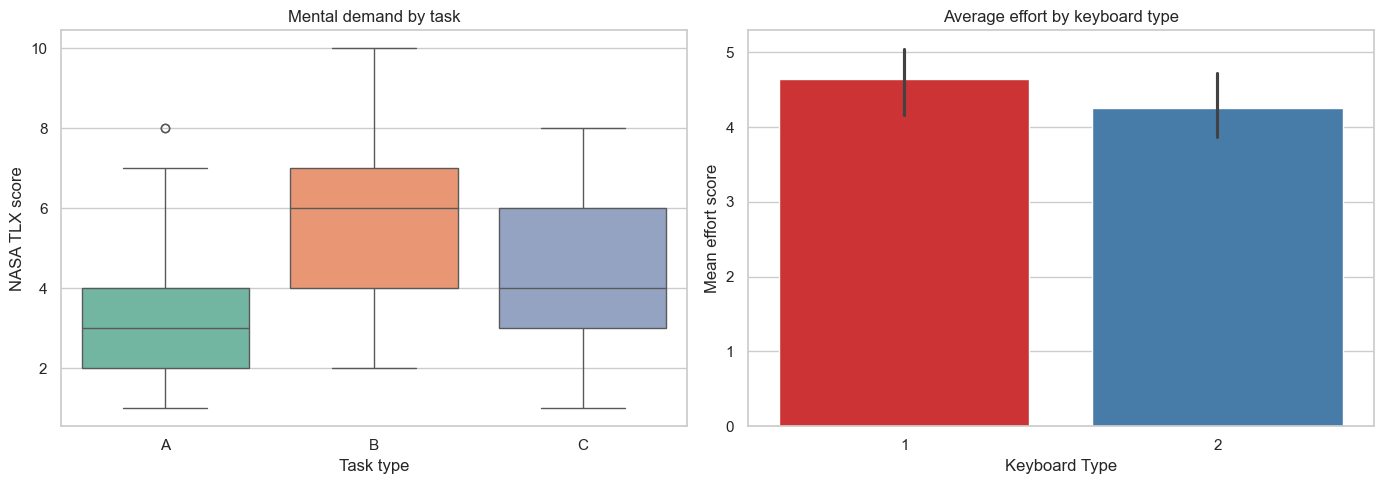

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=nasa_tlx_df, x="Task Type", y="Mental Demand", ax=axes[0], palette="Set2")
axes[0].set_title("Mental demand by task")
axes[0].set_xlabel("Task type")
axes[0].set_ylabel("NASA TLX score")

sns.barplot(
    data=nasa_tlx_df,
    x="Keyboard Type",
    y="Effort",
    estimator=np.mean,
    errorbar=("ci", 95),
    palette="Set1",
    ax=axes[1],
)
axes[1].set_title("Average effort by keyboard type")
axes[1].set_ylabel("Mean effort score")
plt.tight_layout()


#### NASA TLX dataset: correlation between workload dimensions


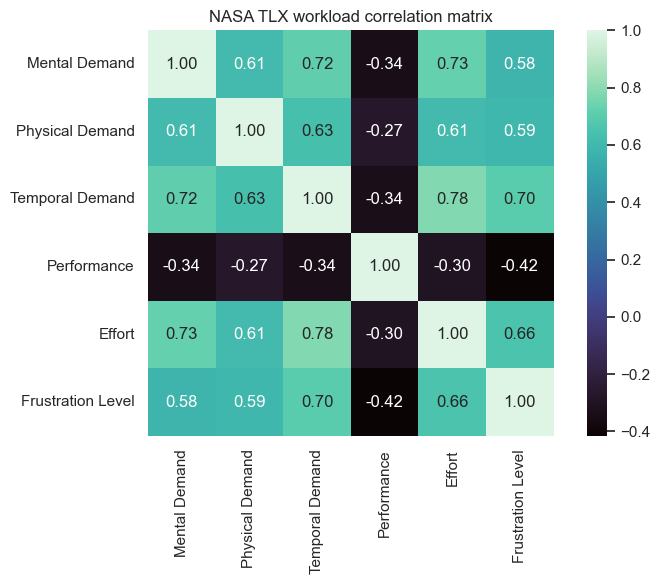

In [36]:
nasa_corr = nasa_tlx_df[workload_cols].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(nasa_corr, cmap="mako", annot=True, fmt=".2f", square=True)
plt.title("NASA TLX workload correlation matrix")
plt.tight_layout()


### Quick takeaways
- Typing performance varies widely (Text_60_WPM ranges from the mid-30s to 100+ WPM) yet accuracies remain clustered above 80%. Higher WPM tasks (e.g., Text_100) introduce broader variance, especially for numerical/programming passages.
- Group-level summaries suggest Groups 3–4 generally have the fastest typing speeds in both 60 and 100 WPM tasks, whereas Groups 1–2 show more dispersion.
- Correlation analysis shows positive relationships between each mode's WPM and accuracy, indicating faster typists in this sample also tend to stay accurate; programming tasks at 100 WPM are the most weakly correlated with their 60 WPM counterparts, hinting at modality-specific skills.
- NASA TLX scores skew toward moderate workloads (means ~4–5), but Task Type B elicits noticeably higher mental demand and effort across keyboard types.
- Keyboard Type 2 scenarios trend toward higher effort/frustration than Type 1, and workload dimensions are strongly interrelated (e.g., effort/frustration correlation >0.8).
